In [2]:
#import  libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset for Week 2 data understanding (use first column as index)
df_dc2 = pd.read_csv('../datasets/data_dc2.csv', index_col=0)
df_dc2

,x,y,class
0,-1.679040,500.804975,2.0
1,-1.045952,501.360254,1.0
2,-1.120480,501.528549,1.0
3,-1.689251,498.098798,2.0
4,-0.929261,501.025551,1.0
...,...,...,...
235,1.535065,500.782883,0.0
236,-0.489350,498.856495,2.0
237,-1.022125,498.653837,2.0
238,-1.138651,498.587498,2.0


## Data Summary

### 1. Data Types
### 2. Distribution
### 3. Statistics

In [4]:
# 1. DATA TYPES - Check the structure and types of data
print("-"*70)
print("DATA TYPES")
print("-"*70)
print(f"\nDataset shape: {df_dc2.shape[0]} rows × {df_dc2.shape[1]} columns\n")
print(df_dc2.info())
print("\nData types summary:")
print(df_dc2.dtypes)

----------------------------------------------------------------------
DATA TYPES
----------------------------------------------------------------------

Dataset shape: 240 rows × 3 columns

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 239
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       240 non-null    float64
 1   y       240 non-null    float64
 2   class   240 non-null    float64
dtypes: float64(3)
memory usage: 7.5 KB
None

Data types summary:
x        float64
y        float64
class    float64
dtype: object


In [5]:
# DATA QUALITY CHECKS
print("="*70)
print("DATA QUALITY CHECKS")
print("="*70)

# 1. Missing Values
print("\n1. MISSING VALUES:")
print(df_dc2.isnull().sum())

# 2. Unusual Values (Outliers)
print("\n2. UNUSUAL VALUES (Outliers using IQR):")
for col in ['x', 'y']:
    Q1, Q3 = df_dc2[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df_dc2[(df_dc2[col] < Q1 - 1.5*IQR) | (df_dc2[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_dc2)*100:.1f}%)")

# 3. Invalid Values
print("\n3. INVALID VALUES:")
print(f"Infinite values: {np.isinf(df_dc2.select_dtypes(include=[np.number])).sum().sum()}")
print(f"Duplicate rows: {df_dc2.duplicated().sum()}")
print(f"Invalid classes: {len(df_dc2[~df_dc2['class'].isin([0.0, 1.0, 2.0])])}")

DATA QUALITY CHECKS

1. MISSING VALUES:
x        0
y        0
class    0
dtype: int64

2. UNUSUAL VALUES (Outliers using IQR):
x: 4 outliers (1.7%)
y: 0 outliers (0.0%)

3. INVALID VALUES:
Infinite values: 0
Duplicate rows: 0
Invalid classes: 0


----------------------------------------------------------------------
DISTRIBUTION
----------------------------------------------------------------------

Class distribution:
class
0.0    78
1.0    79
2.0    83
Name: count, dtype: int64


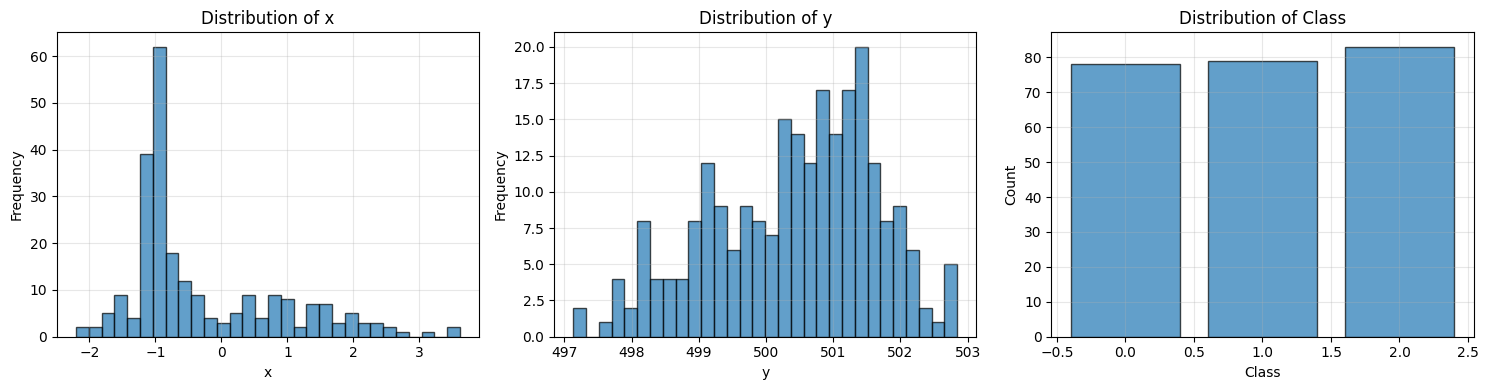

In [6]:
# 2. DISTRIBUTION - Visualize how the data is distributed
print("-"*70)
print("DISTRIBUTION")
print("-"*70)

# Value counts for categorical data
print("\nClass distribution:")
print(df_dc2['class'].value_counts().sort_index())

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# X distribution
axes[0].hist(df_dc2['x'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of x')
axes[0].grid(alpha=0.3)

# Y distribution
axes[1].hist(df_dc2['y'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('y')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of y')
axes[1].grid(alpha=0.3)

# Class distribution
class_counts = df_dc2['class'].value_counts().sort_index()
axes[2].bar(class_counts.index, class_counts.values, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')
axes[2].set_title('Distribution of Class')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# 3. STATISTICS - Calculate descriptive statistics
print("-"*70)
print("STATISTICS")
print("-"*70)

# Overall statistics
print("\nDescriptive statistics for all columns:")
print(df_dc2.describe(include='all'))

# Statistics by class
print("\n" + "="*70)
print("Statistics grouped by class:")
print("="*70)
for class_num in sorted(df_dc2['class'].unique()):
    print(f"\n--- Class {int(class_num)} ---")
    class_data = df_dc2[df_dc2['class'] == class_num][['x', 'y']]
    print(class_data.describe())
    
# Correlation matrix
print("\n" + "="*70)
print("Correlation matrix:")
print("="*70)
print(df_dc2.corr())

----------------------------------------------------------------------
STATISTICS
----------------------------------------------------------------------

Descriptive statistics for all columns:
                x           y       class
count  240.000000  240.000000  240.000000
mean    -0.289897  500.411932    1.020833
std      1.168741    1.237191    0.820490
min     -2.199979  497.131782    0.000000
25%     -1.038295  499.514773    0.000000
50%     -0.867815  500.577801    1.000000
75%      0.461837  501.343770    2.000000
max      3.612597  502.844227    2.000000

Statistics grouped by class:

--- Class 0 ---
               x           y
count  78.000000   78.000000
mean    1.108037  501.042053
std     0.961284    0.660919
min    -1.098161  499.368736
25%     0.461837  500.526660
50%     1.060097  501.072221
75%     1.678185  501.431292
max     3.612597  502.818378

--- Class 1 ---
               x           y
count  79.000000   79.000000
mean   -1.002280  501.173321
std     0.089345

In [8]:
# Basic info and descriptive statistics
df_dc2.info()
df_dc2.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 239
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       240 non-null    float64
 1   y       240 non-null    float64
 2   class   240 non-null    float64
dtypes: float64(3)
memory usage: 7.5 KB


,x,y,class
count,240.000000,240.000000,240.000000
mean,-0.289897,500.411932,1.020833
std,1.168741,1.237191,0.820490
min,-2.199979,497.131782,0.000000
25%,-1.038295,499.514773,0.000000
50%,-0.867815,500.577801,1.000000
75%,0.461837,501.343770,2.000000
max,3.612597,502.844227,2.000000


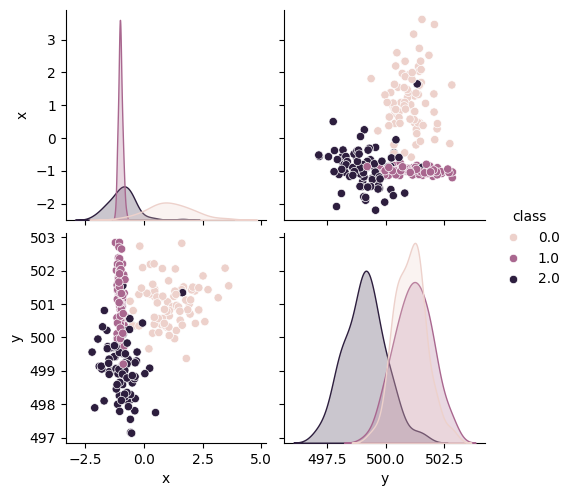

In [9]:
sns.pairplot(df_dc2, hue='class')

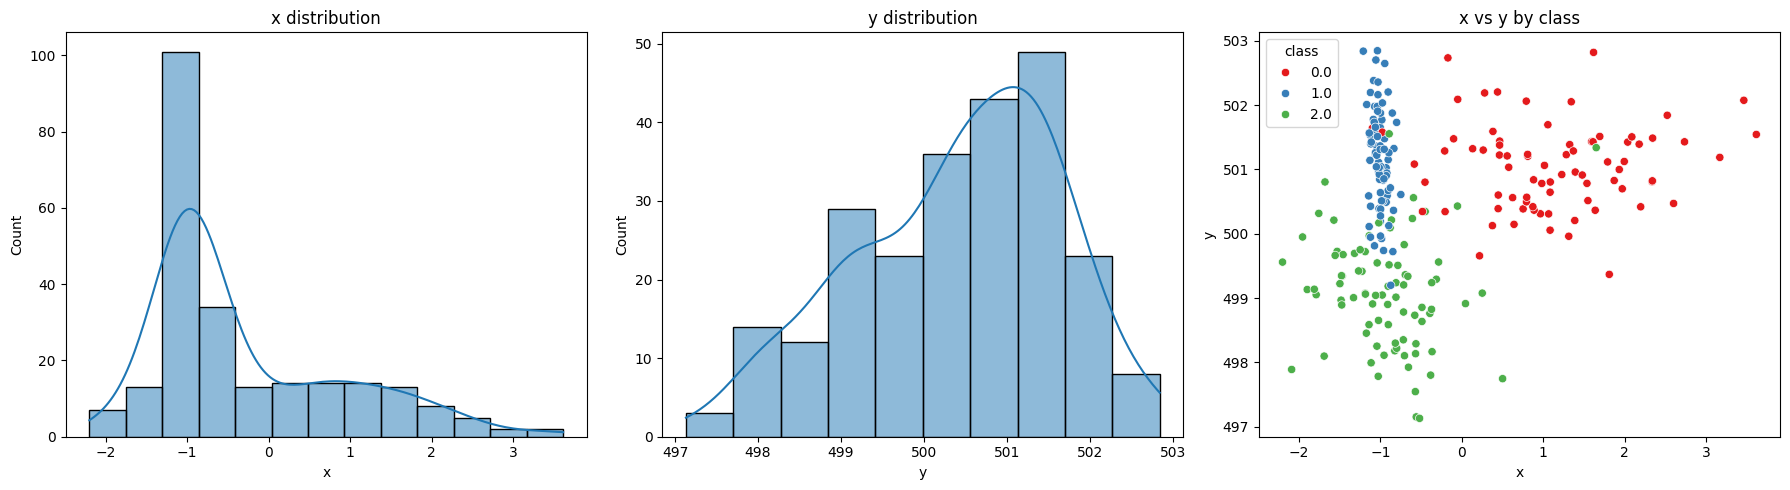

In [ ]:
#Plot 1 
#Create the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Plot x distribution
sns.histplot(df_dc2['x'], kde=True, ax=axes[0])
axes[0].set_title('x distribution')

#Plot y distribution
sns.histplot(df_dc2['y'], kde=True, ax=axes[1])
axes[1].set_title('y distribution')

#Plot x vs y by class
sns.scatterplot(data=df_dc2, x='x', y='y', hue='class', palette='Set1', ax=axes[2])
axes[2].set_title('x vs y by class')

plt.tight_layout()
plt.show()

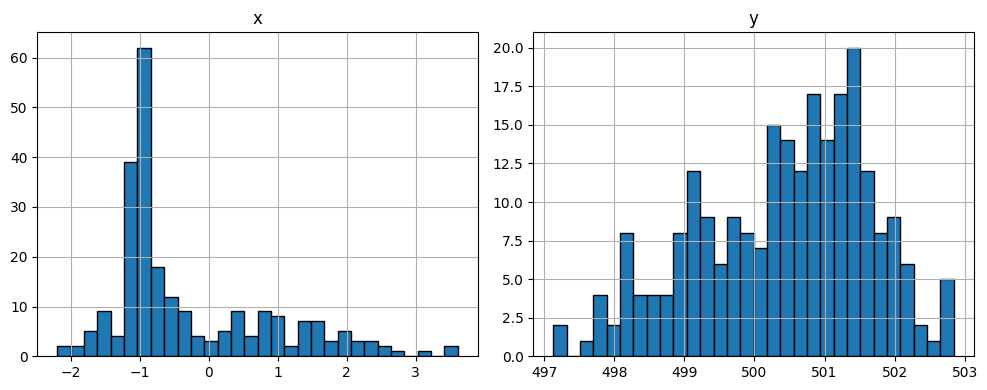

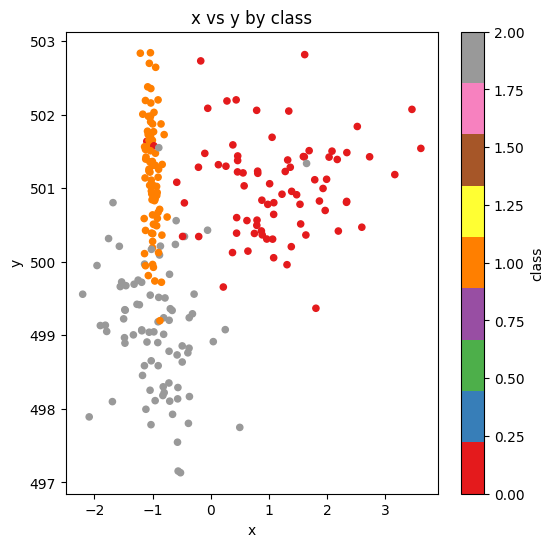

In [ ]:
#Plot 2 pandas plots
df_dc2[['x', 'y']].hist(bins=30, figsize=(10, 4), edgecolor='black')
plt.tight_layout()
plt.show()

df_dc2.plot.scatter(x='x', y='y', c='class', colormap='Set1', figsize=(6, 6))
plt.title('x vs y by class')
plt.show()